In [66]:
from dlfs.layers import EmbeddingLayer, PositionalEncoding, DenseLayer
from dlfs.modules import Transformer

from dlfs.activation import Softmax, ReLU
from dlfs.loss import CCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.base import Module

import numpy as np

In [67]:
class TransformerModel(Module):

    def __init__(self, vocab_size=12, block_size=5, 
                       n_embed=512, n_head = 4, n_enc_layers=2, n_dec_layers=2, dim_ff=2048, 
                       dropout=0.1, activation=ReLU(), layer_norm_eps=1e-5, loss_function=None, optimizer=None):
        
        self.loss_function = loss_function
        self.optimizer = optimizer

        self.embed_enc = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc_enc = PositionalEncoding(block_size, n_embed)

        self.embed_dec = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc_dec = PositionalEncoding(block_size, n_embed)

        self.transformer = Transformer(d_model=n_embed, n_head=n_head, n_enc_layers=n_enc_layers, n_dec_layers=n_dec_layers,
                                       dim_ff=dim_ff, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps)

        self.linear = DenseLayer(n_embed, vocab_size)
        self.softm = Softmax()

    def forward(self, inputs_enc, inputs_dec, training):
        self.embed_enc.forward(inputs_enc, training)
        self.pos_enc_enc.forward(self.embed_enc.output, training)

        self.embed_dec.forward(inputs_dec, training)
        self.pos_enc_dec.forward(self.embed_dec.output, training)

        self.transformer.forward(self.pos_enc_enc.output, self.pos_enc_dec.output, training)

        self.linear.forward(self.transformer.output)

        self.output = self.linear.output

    def backward(self, output, y):
        y_pred = output
        B, T, C = y_pred.shape
        y_pred = y_pred.reshape(B*T, C)
        y_true = y.reshape(B*T)

        self.loss_function.backward(y_pred, y_true)

        self.linear.backward(self.loss_function.dinputs.reshape(B, T, C))

        self.transformer.backward(self.linear.dinputs)

        self.pos_enc_dec.backward(self.transformer.decoder_dinputs)
        self.embed_dec.backward(self.pos_enc_dec.dinputs)

        self.pos_enc_enc.backward(self.transformer.encoder_dinputs)
        self.embed_enc.backward(self.pos_enc_enc.dinputs)

    def train(self, X, y_dec, y_true, epochs = 1000, batch_size: int = None, print_every: int = None):

        self.loss_vals = []

        for i in range(epochs + 1):
            #batch_X, batch_y_dec, batch_y_true = get_random_batch(X, y_dec, y_true, batch_size)
            #batch_X, batch_y_dec, batch_y_true = batch_X.astype(int), batch_y_dec.astype(int), batch_y_true.astype(int)

            self.forward(X, y_dec, training=True)
            
            self.backward(self.output, y_true)

            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            B, T, C = self.output.shape
            self.loss_vals.append(self.loss_function.calculate(self.output.reshape(B*T, C), y_true.reshape(B*T)))

            if print_every is not None and not i % print_every:
                output = self.output
                B, T, C = output.shape
                print(f'===== EPOCH : {i} ===== LOSS : {self.loss_function.calculate(output.reshape(B*T, C), y_true.reshape(B*T))} =====')
                
    def generate(self, inputs_enc, max_len=5, start_token=10, end_token=11):
        """
        Generate output sequence given input encoding.
        
        inputs_enc: np.ndarray of shape (batch_size, source_seq_len)
        max_len: max length of generated sequence
        start_token: int, index of <SOS> token
        end_token: int, index of <EOS> token
        
        Returns:
            generated sequences of shape (batch_size, generated_seq_len)
        """
        batch_size = inputs_enc.shape[0]
        
        # Run encoder once
        self.embed_enc.forward(inputs_enc, training=False)
        self.pos_enc_enc.forward(self.embed_enc.output, training=False)
        self.transformer._encoder_forward(self.pos_enc_enc.output, training=False)

        encoder_output = self.transformer.encoder_output
        
        # Initialize decoder input with start tokens (shape: batch_size x 1)
        decoder_input = np.full((batch_size, 1), start_token, dtype=int)
        
        generated = decoder_input.copy()
        
        for _ in range(max_len):
            # Decoder forward pass for current decoder input
            self.embed_dec.forward(decoder_input, training=False)
            self.pos_enc_dec.forward(self.embed_dec.output, training=False)

            self.transformer._decoder_forward(self.pos_enc_dec.output, encoder_output, training=False)

            self.linear.forward(self.transformer.decoder_output, training=False)
            self.softm.forward(self.linear.output, training=False)
            
            # Get last timestep prediction probs (batch_size, vocab_size)
            probs = self.softm.output[:, -1, :]
            
            # Greedy decode: pick the highest probability token for each example
            next_tokens = np.argmax(probs, axis=1).reshape(-1, 1)
            
            # Append to generated sequences
            generated = np.concatenate([generated, next_tokens], axis=1)
            
            # Prepare next decoder input
            decoder_input = generated
            
            # Stop if all sequences generated <EOS>
            if np.all(next_tokens == end_token):
                break
        
        return generated

# Dummy dataset, helper functions

In [ ]:
def generate_reverse_dataset(num_samples=1000, seq_length=5, vocab_size=10):
    """
    Generate a toy dataset for sequence reversal.
    Each input is a sequence of integers (1 to vocab_size).
    The output is the reversed version of the input.
    """
    X = np.random.randint(1, vocab_size+1, size=(num_samples, seq_length))
    y = np.flip(X, axis=1)
    return X, y

def prepare_transformer_input(X, y, sos_token=0):
    """
    Prepares encoder and decoder inputs for transformer training.
    Decoder sequences start with a 'start-of-sequence' token (sequences shifted right, SOS token placed in front)
    """
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:] = y[:, :-1]
    decoder_input[:, 0] = sos_token  # start-of-sequence token

    return X, decoder_input, y

def get_random_batch(X, y_dec, y_true, batch_size):
    idx = np.random.randint(0, len(X), size=(batch_size, ))
    return X[idx], y_dec[idx], y_true[idx]

# Create and preprocess data

In [ ]:
X_train, y_train = generate_reverse_dataset(num_samples=100, seq_length=5, vocab_size=20)

X_train, y_decoder_train, y_train = prepare_transformer_input(X_train, y_train, sos_token=0)
print(X_train[:2], "\n-----")
print(y_decoder_train[:2], "\n-----")
print(y_train[:2], "\n-----")

[[ 4  1  3 14  9]
 [ 5  9 12 19  2]]
[[ 0  9 14  3  1]
 [ 0  2 19 12  9]]
[[ 9 14  3  1  4]
 [ 2 19 12  9  5]]


# Model creation, hyperparameters

In [70]:
np.random.seed(1)

vocab_size = max(max(X_train.flatten()), max(y_train.flatten())) + 1
block_size = X_train.shape[-1]
batch_size = None

n_embed = 128
n_head = 8
n_enc_layers = 1
n_dec_layers = 1
dim_ff = 128
dropout = 0.
eps = 1e-5

epochs = 1000
lr = 1e-4

loss = CCE_Loss(from_logits=True)
optimizer = Optimizer_Adam(learning_rate=lr, decay=0., clip_grad=False, beta_1=0.8, beta_2=0.8)

model = TransformerModel(vocab_size=vocab_size, 
                         block_size=block_size, 
                         n_embed=n_embed, 
                         n_head=n_head,
                         n_enc_layers=n_enc_layers,
                         n_dec_layers=n_dec_layers, 
                         dim_ff=dim_ff, 
                         dropout=dropout,
                         layer_norm_eps=eps,
                         loss_function=loss, 
                         optimizer=optimizer)

model.train(X_train, y_decoder_train, y_train, print_every=100, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 11.99373827335632 =====
===== EPOCH : 100 ===== LOSS : 2.5693855347343884 =====
===== EPOCH : 200 ===== LOSS : 1.9364736285065 =====
===== EPOCH : 300 ===== LOSS : 1.1046555302338639 =====
===== EPOCH : 400 ===== LOSS : 0.37236799083223565 =====
===== EPOCH : 500 ===== LOSS : 0.05086177401229514 =====


KeyboardInterrupt: 

# Loss plotting

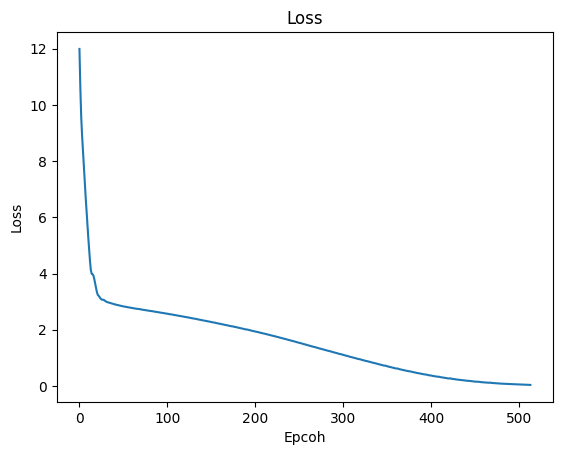

In [71]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_vals)), model.loss_vals)
plt.title("Loss")
plt.xlabel("Epcoh")
plt.ylabel("Loss")
plt.show()

In [74]:
result = model.generate(X_train, start_token=0, max_len=block_size)

print(result[:5])
print(y_train[:5])

[[ 0  9 14  3  1  4]
 [ 0  2 19 12  9  5]
 [ 0 13 18 13 15  7]
 [ 0 10 17  7 14 15]
 [ 0 11  8  8 18 13]]
[[ 9 14  3  1  4]
 [ 2 19 12  9  5]
 [13 18 13 15  7]
 [10 17  7 14 15]
 [11  8  8 18 13]]


In [75]:
X_test = np.array([[2, 4, 6, 8, 10],
                   [15, 12, 9, 6, 3]])

y_test = np.array([[10, 8, 6, 4, 2],
                   [3, 6, 9, 12, 15]])

result = model.generate(X_test, start_token=0, max_len=block_size)

print(result[:5])
print(y_test[:5])

[[ 0 10  8  6  4  2]
 [ 0  3  6  9 12 15]]
[[10  8  6  4  2]
 [ 3  6  9 12 15]]
